In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request

os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
urllib.request.urlretrieve(url, "banknote.csv")

cols = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv("banknote.csv", header=None, names=cols)
df.to_csv("results/raw_dataset.csv", index=False)
print(df.shape)
df.head()

def style_and_save(fig, axes, filename, caption, xlabel=None, ylabel=None, has_legend=False):
    axes_list = axes if isinstance(axes, (list, np.ndarray)) else [axes]
    for ax in np.array(axes_list).flatten():
        if xlabel: ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=11)
        if ylabel: ax.set_ylabel(ax.get_ylabel(), fontweight='bold', fontsize=11)
        ax.set_xlabel(ax.get_xlabel(), fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontweight='bold')
        if has_legend and ax.get_legend():
            leg = ax.get_legend()
            for text in leg.get_texts():
                text.set_fontweight('bold')
    fig.text(0.5, -0.03, caption, wrap=True, ha='center', fontsize=9, style='italic')
    fig.savefig(f"results/plots/{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    plt.show()

(1372, 5)


Task 1: Dataset Exploration

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive stats:\n", df.describe())
df.describe().to_csv("results/descriptive_stats.csv")

Shape: (1372, 5)

Missing values:
 Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive stats:
           Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


Task 2: EDA Plots

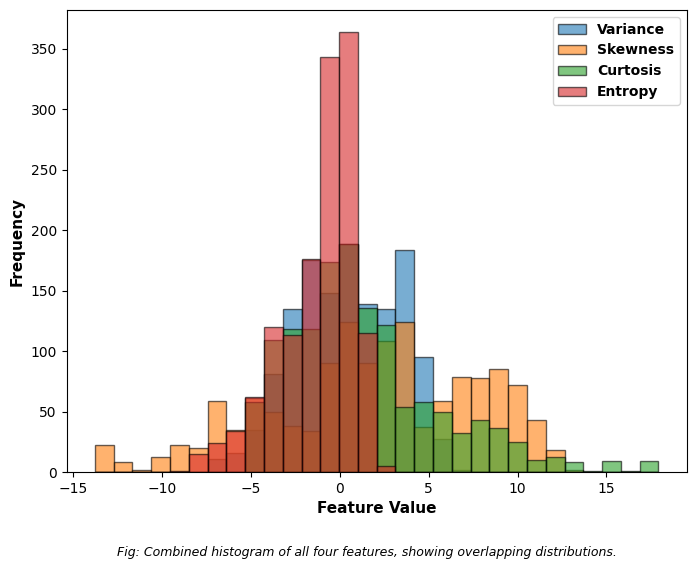

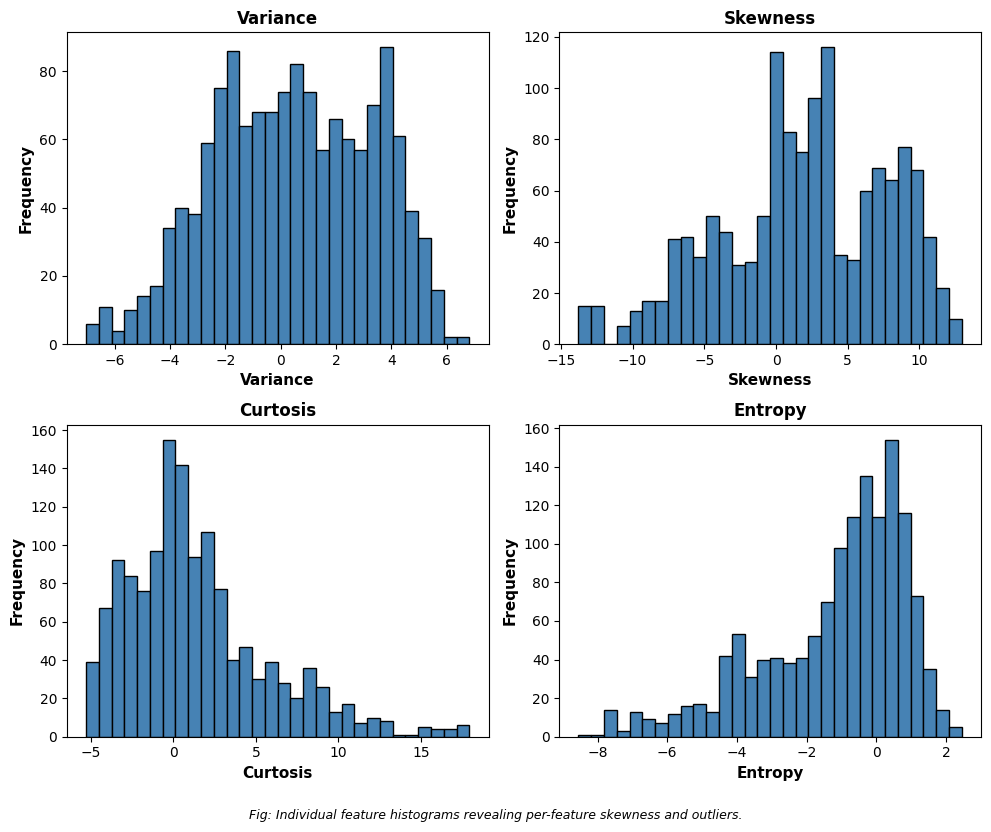

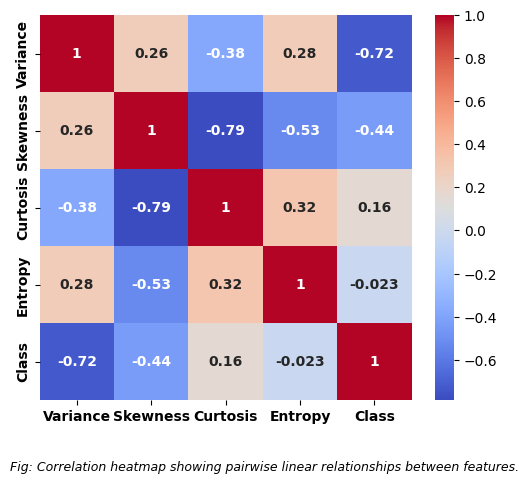

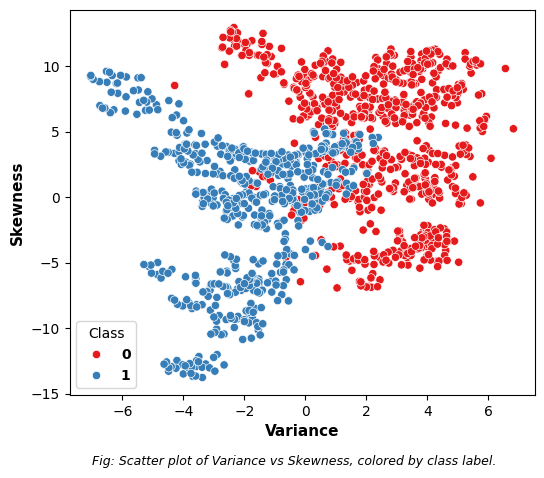

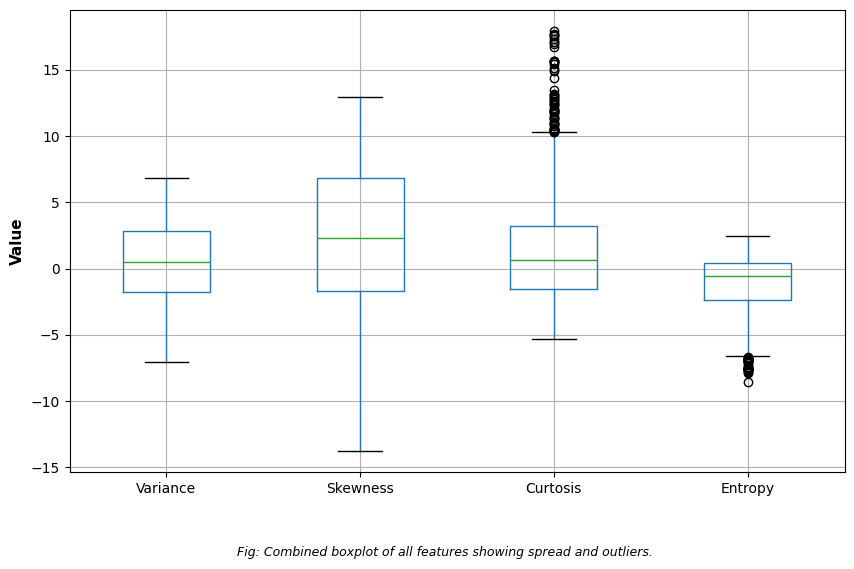

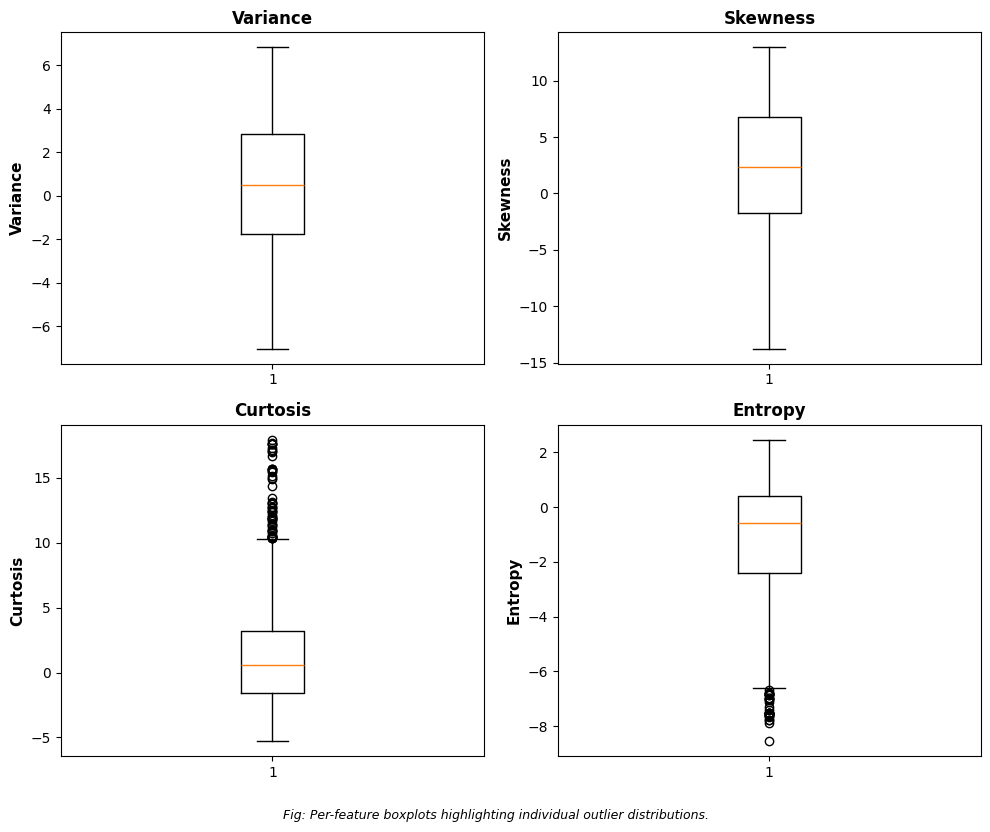

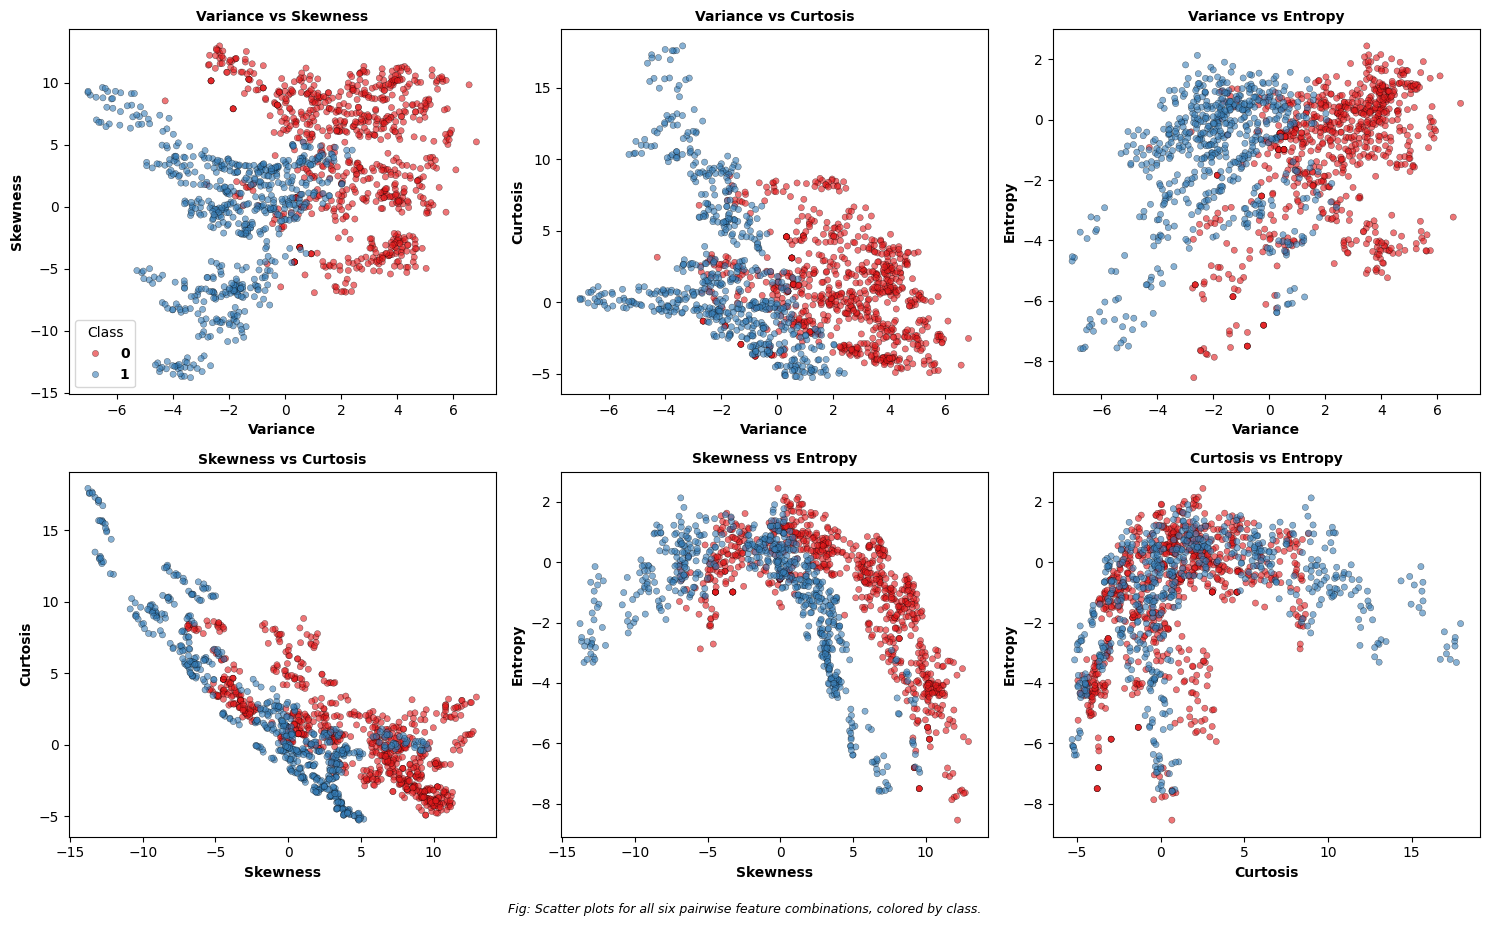

In [ ]:
# Combined histogram (all features)
fig, ax = plt.subplots(figsize=(8,6))
df.drop("Class", axis=1).plot(kind='hist', bins=30, alpha=0.6, ax=ax, edgecolor='black')
ax.set_xlabel("Feature Value"); ax.set_ylabel("Frequency")
style_and_save(fig, ax, "histograms_combined",
    "Fig: Combined histogram of all four features, showing overlapping distributions.",
    xlabel=True, ylabel=True, has_legend=True)

# Per-feature histogram subplots
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for i, col in enumerate(["Variance","Skewness","Curtosis","Entropy"]):
    ax = axes.flatten()[i]
    ax.hist(df[col], bins=30, edgecolor='black', color='steelblue')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel("Frequency")
plt.tight_layout()
style_and_save(fig, axes, "histograms_subplots",
    "Fig: Individual feature histograms revealing per-feature skewness and outliers.",
    xlabel=True, ylabel=True)

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=ax,
            annot_kws={"fontweight":"bold"})
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')
style_and_save(fig, ax, "correlation_heatmap",
    "Fig: Correlation heatmap showing pairwise linear relationships between features.")

# Scatter plot
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=df, x="Variance", y="Skewness", hue="Class", palette="Set1", ax=ax)
ax.set_xlabel("Variance"); ax.set_ylabel("Skewness")
style_and_save(fig, ax, "scatter_plot",
    "Fig: Scatter plot of Variance vs Skewness, colored by class label.",
    xlabel=True, ylabel=True, has_legend=True)

# Boxplots (combined)
fig, ax = plt.subplots(figsize=(10,6))
df.drop("Class", axis=1).boxplot(ax=ax)
ax.set_ylabel("Value")
style_and_save(fig, ax, "boxplots_combined",
    "Fig: Combined boxplot of all features showing spread and outliers.",
    ylabel=True)

# Boxplots (per feature subplots)
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for i, col in enumerate(["Variance","Skewness","Curtosis","Entropy"]):
    ax = axes.flatten()[i]
    ax.boxplot(df[col])
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)
plt.tight_layout()
style_and_save(fig, axes, "boxplots_subplots",
    "Fig: Per-feature boxplots highlighting individual outlier distributions.",
    ylabel=True)



from itertools import combinations

features = ["Variance", "Skewness", "Curtosis", "Entropy"]
pairs = list(combinations(features, 2))  # 6 pairs

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (f1, f2) in enumerate(pairs):
    ax = axes[i]
    sns.scatterplot(data=df, x=f1, y=f2, hue="Class", palette="Set1",
                     ax=ax, alpha=0.6, s=20, edgecolor='k', linewidth=0.3, legend=(i==0))
    ax.set_xlabel(f1, fontweight='bold')
    ax.set_ylabel(f2, fontweight='bold')
    ax.set_title(f"{f1} vs {f2}", fontweight='bold', fontsize=10)

if axes[0].get_legend():
    for text in axes[0].get_legend().get_texts():
        text.set_fontweight('bold')

plt.tight_layout()
fig.text(0.5, -0.02, "Fig: Scatter plots for all six pairwise feature combinations, colored by class.",
          ha='center', fontsize=9, style='italic')
fig.savefig("results/plots/scatter_all_pairs.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

Task 3: Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1).values
y = df["Class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1097, 4) Test: (275, 4)


Task 4 & 5: Perceptron from Scratch

In [ ]:
class Perceptron:
    def __init__(self, n_features, lr=0.01, epochs=50, seed=42):
        rng = np.random.default_rng(seed)
        self.w = rng.normal(0, 0.01, n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        self.history = {"epoch": [], "errors": [], "weights": [], "bias": []}

    def step(self, z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        return self.step(X @ self.w + self.b)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.epochs + 1):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.w) + self.b
                y_hat = self.step(z)
                update = self.lr * (target - y_hat)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    errors += 1

            self.history["epoch"].append(epoch)
            self.history["errors"].append(errors)
            self.history["weights"].append(self.w.copy())
            self.history["bias"].append(self.b)

            if verbose:
                print(f"Epoch {epoch:02d} | Misclassified: {errors} | "
                      f"Weights: {np.round(self.w,4)} | Bias: {round(self.b,4)}")

            if errors == 0:
                break
        return self

Train Main Model

In [ ]:
model = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50)
model.fit(X_train, y_train)

# Save epoch-wise log
log_df = pd.DataFrame({
    "Epoch": model.history["epoch"],
    "Errors": model.history["errors"],
    "Weights": [list(np.round(w,4)) for w in model.history["weights"]],
    "Bias": np.round(model.history["bias"], 4)
})
log_df.to_csv("results/epoch_log.csv", index=False)
log_df

Epoch 01 | Misclassified: 51 | Weights: [-0.0626 -0.0793 -0.0635 -0.0028] | Bias: -0.03
Epoch 02 | Misclassified: 24 | Weights: [-0.0762 -0.1023 -0.0646 -0.0003] | Bias: -0.03
Epoch 03 | Misclassified: 23 | Weights: [-0.078  -0.0965 -0.0914 -0.0022] | Bias: -0.04
Epoch 04 | Misclassified: 32 | Weights: [-0.0886 -0.1127 -0.098  -0.0056] | Bias: -0.06
Epoch 05 | Misclassified: 26 | Weights: [-0.0967 -0.1214 -0.1062 -0.0061] | Bias: -0.06
Epoch 06 | Misclassified: 20 | Weights: [-0.1096 -0.1347 -0.104  -0.0023] | Bias: -0.04
Epoch 07 | Misclassified: 23 | Weights: [-0.1161 -0.1428 -0.1101 -0.0042] | Bias: -0.05
Epoch 08 | Misclassified: 20 | Weights: [-0.1059 -0.1432 -0.1247 -0.0002] | Bias: -0.07
Epoch 09 | Misclassified: 23 | Weights: [-0.1249 -0.1533 -0.1172  0.0035] | Bias: -0.06
Epoch 10 | Misclassified: 18 | Weights: [-0.1199 -0.1608 -0.1236  0.0092] | Bias: -0.06
Epoch 11 | Misclassified: 17 | Weights: [-0.1248 -0.1561 -0.1333  0.0045] | Bias: -0.07
Epoch 12 | Misclassified: 18 | W

,Epoch,Errors,Weights,Bias
0,1,51,"[-0.0626, -0.0793, -0.0635, -0.0028]",-0.03
1,2,24,"[-0.0762, -0.1023, -0.0646, -0.0003]",-0.03
2,3,23,"[-0.078, -0.0965, -0.0914, -0.0022]",-0.04
3,4,32,"[-0.0886, -0.1127, -0.098, -0.0056]",-0.06
4,5,26,"[-0.0967, -0.1214, -0.1062, -0.0061]",-0.06
5,6,20,"[-0.1096, -0.1347, -0.104, -0.0023]",-0.04
6,7,23,"[-0.1161, -0.1428, -0.1101, -0.0042]",-0.05
7,8,20,"[-0.1059, -0.1432, -0.1247, -0.0002]",-0.07
8,9,23,"[-0.1249, -0.1533, -0.1172, 0.0035]",-0.06
9,10,18,"[-0.1199, -0.1608, -0.1236, 0.0092]",-0.06


Task 6: Evaluation

Accuracy: 0.9891
Precision: 0.9837
Recall: 0.9918
F1-score: 0.9878
Confusion Matrix:
 [[151   2]
 [  1 121]]


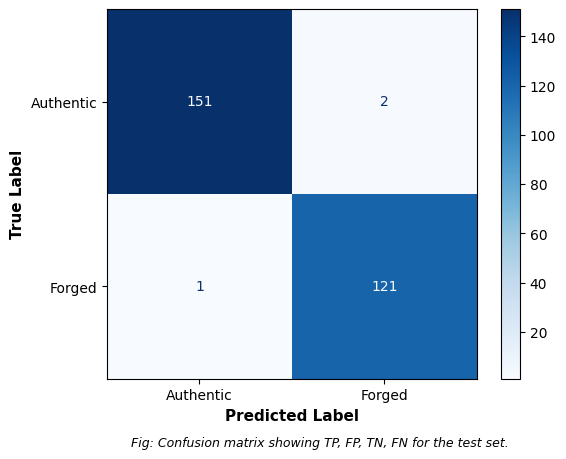

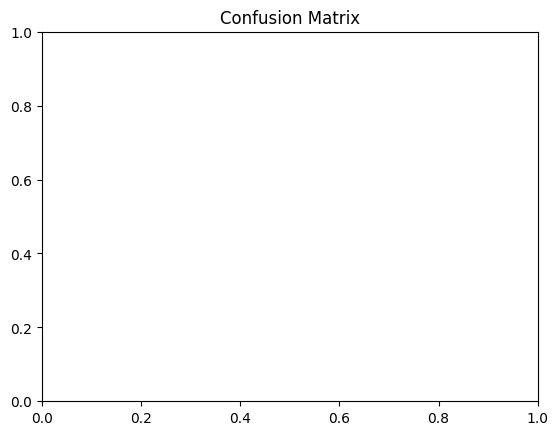

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

pd.DataFrame({"Metric": ["Accuracy","Precision","Recall","F1-score"],
              "Value": [acc, prec, rec, f1]}).to_csv("results/final_metrics.csv", index=False)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic","Forged"])
fig, ax = plt.subplots()
disp.plot(cmap="Blues", ax=ax)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
style_and_save(fig, ax, "confusion_matrix",
    "Fig: Confusion matrix showing TP, FP, TN, FN for the test set.",
    xlabel=True, ylabel=True)
plt.title("Confusion Matrix")
plt.savefig("results/plots/confusion_matrix.png", dpi=150)
plt.show()

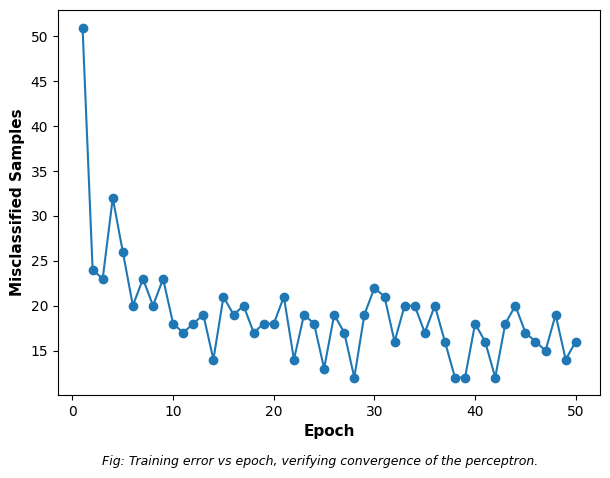

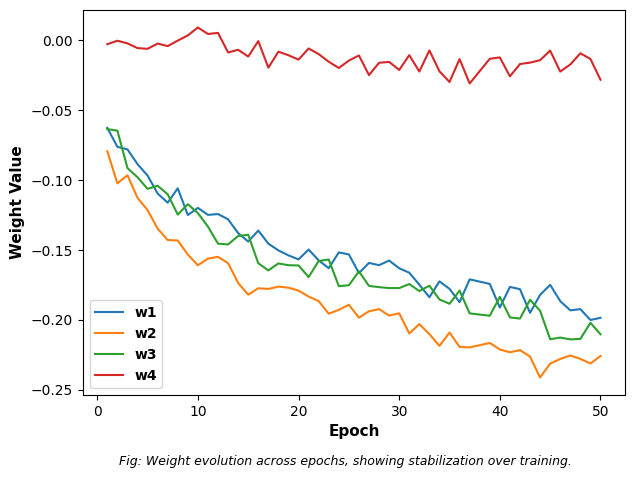

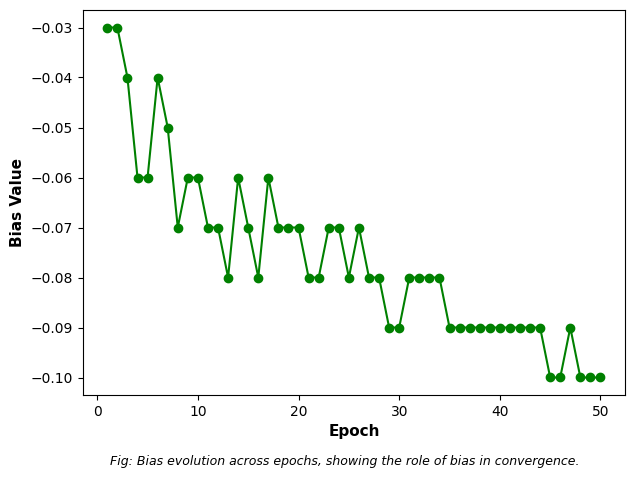

In [ ]:
epochs = model.history["epoch"]
errors = model.history["errors"]
weights = np.array(model.history["weights"])
biases = model.history["bias"]

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(epochs, errors, marker='o')
ax.set_xlabel("Epoch"); ax.set_ylabel("Misclassified Samples")
style_and_save(fig, ax, "error_vs_epoch",
    "Fig: Training error vs epoch, verifying convergence of the perceptron.",
    xlabel=True, ylabel=True)

fig, ax = plt.subplots(figsize=(7,5))
for i in range(weights.shape[1]):
    ax.plot(epochs, weights[:,i], label=f"w{i+1}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Weight Value")
ax.legend()
style_and_save(fig, ax, "weight_evolution",
    "Fig: Weight evolution across epochs, showing stabilization over training.",
    xlabel=True, ylabel=True, has_legend=True)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(epochs, biases, marker='o', color='green')
ax.set_xlabel("Epoch"); ax.set_ylabel("Bias Value")
style_and_save(fig, ax, "bias_evolution",
    "Fig: Bias evolution across epochs, showing the role of bias in convergence.",
    xlabel=True, ylabel=True)

 Task 7: Learning Rate Comparison

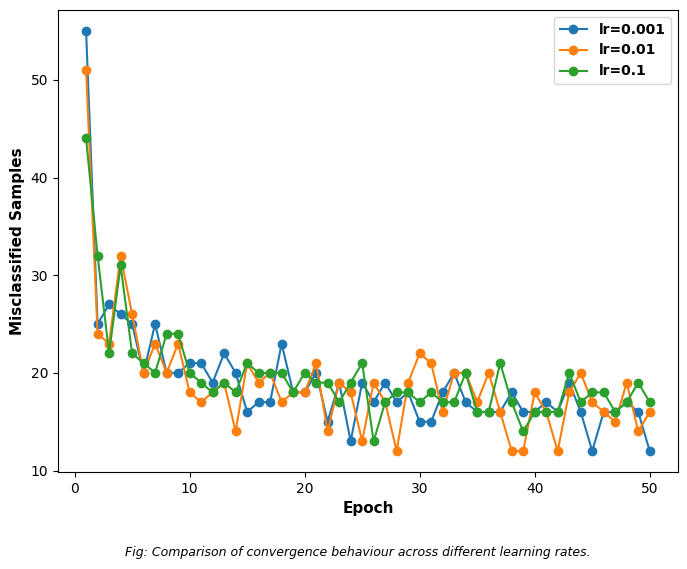

,Learning Rate,Final Train Errors,Avg Errors (last 10 epochs),Test Accuracy,Test F1
0,0.001,12,15.7,0.978182,0.975806
1,0.010,16,16.3,0.989091,0.987755
2,0.100,17,17.4,0.981818,0.979920


In [ ]:
lrs = [0.001, 0.01, 0.1]
lr_results = {}

fig, ax = plt.subplots(figsize=(8,6))
for lr in lrs:
    m = Perceptron(n_features=X_train.shape[1], lr=lr, epochs=50)
    m.fit(X_train, y_train, verbose=False)
    lr_results[lr] = m.history["errors"]
    ax.plot(m.history["epoch"], m.history["errors"], marker='o', label=f"lr={lr}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Misclassified Samples")
ax.legend()
style_and_save(fig, ax, "lr_comparison",
    "Fig: Comparison of convergence behaviour across different learning rates.",
    xlabel=True, ylabel=True, has_legend=True)
lr_summary = []
for lr in lrs:
    m = Perceptron(n_features=X_train.shape[1], lr=lr, epochs=50)
    m.fit(X_train, y_train, verbose=False)
    y_pred_lr = m.predict(X_test)
    lr_summary.append({
        "Learning Rate": lr,
        "Final Train Errors": m.history["errors"][-1],
        "Avg Errors (last 10 epochs)": np.mean(m.history["errors"][-10:]),
        "Test Accuracy": accuracy_score(y_test, y_pred_lr),
        "Test F1": f1_score(y_test, y_pred_lr)
    })

lr_df = pd.DataFrame(lr_summary)
lr_df.to_csv("results/lr_criteria_comparison.csv", index=False)
lr_df

Sklearn Comparison:

In [ ]:
from sklearn.linear_model import Perceptron as SKPerceptron

sk_model = SKPerceptron(max_iter=50, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

sk_acc = accuracy_score(y_test, sk_pred)
sk_f1 = f1_score(y_test, sk_pred)
print(f"Sklearn Perceptron -> Accuracy: {sk_acc:.4f}, F1: {sk_f1:.4f}")
print(f"Scratch Perceptron -> Accuracy: {acc:.4f}, F1: {f1:.4f}")

pd.DataFrame({
    "Model": ["Scratch", "Sklearn"],
    "Accuracy": [acc, sk_acc],
    "F1": [f1, sk_f1]
}).to_csv("results/model_comparison.csv", index=False)

Sklearn Perceptron -> Accuracy: 0.9745, F1: 0.9721
Scratch Perceptron -> Accuracy: 0.9891, F1: 0.9878


Decision Boundary (2 features)

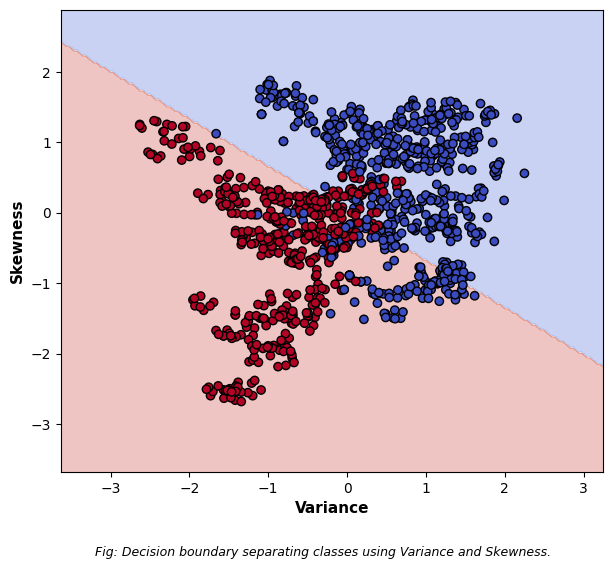

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
ax.scatter(X2[:,0], X2[:,1], c=y_train, cmap="coolwarm", edgecolor='k')
ax.set_xlabel("Variance"); ax.set_ylabel("Skewness")
style_and_save(fig, ax, "decision_boundary",
    "Fig: Decision boundary separating classes using Variance and Skewness.",
    xlabel=True, ylabel=True)

In [ ]:
import pandas as pd
epoch_log = pd.read_csv("/home/ai-ds-a/Downloads/Experiment1_Results(1)/epoch_log.csv")
print(epoch_log[epoch_log['Epoch'].isin([10,25])])

FileNotFoundError: [Errno 2] No such file or directory: '/home/ai-ds-a/Downloads/Experiment1_Results(1)/epoch_log.csv'

In [ ]:
import shutil
shutil.make_archive("Experiment1_Results", 'zip', "results")
from google.colab import files
files.download("Experiment1_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>